<a href="https://colab.research.google.com/github/kxrrym03/Fake-News-Detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving news_dataset.csv to news_dataset.csv


In [3]:
df = pd.read_csv('news_dataset.csv')
df.shape

(6000, 5)

In [4]:
df.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


In [5]:
df.tail()

,title,text,subject,date,label
5995,Exiled Venezuelan opposition magistrates resur...,SANTIAGO (Reuters) - A group of opposition-app...,worldnews,"October 19, 2017",1
5996,Plague outbreak in Madagascar kills 20: WHO,NAIROBI (Reuters) - An outbreak of plague has ...,worldnews,"September 29, 2017",1
5997,"Trump to visit Asia in November, North Korea i...",WASHINGTON (Reuters) - Donald Trump will trave...,worldnews,"September 29, 2017",1
5998,Melania Trump calls taped comments by Donald T...,(Reuters) - Melania Trump rose to her husband’...,politicsNews,"October 18, 2016",1
5999,"#BoycottPenzeys: HATEFUL, DIVISIVE Penzeys Spi...","Bill Penzey, the owner of Penzeys Spices, wrot...",politics,"Dec 2, 2016",0


In [6]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [7]:
df.duplicated().sum()

np.int64(5)

In [8]:
df.drop_duplicates(inplace=True)
df.shape

(5995, 5)

In [9]:
df.describe()

,label
count,5995.000000
mean,0.499583
std,0.500042
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5995 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    5995 non-null   object
 1   text     5995 non-null   object
 2   subject  5995 non-null   object
 3   date     5995 non-null   object
 4   label    5995 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 281.0+ KB


In [11]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [12]:
df.dtypes

,0
title,object
text,object
subject,object
date,object
label,int64


## Data Visualization


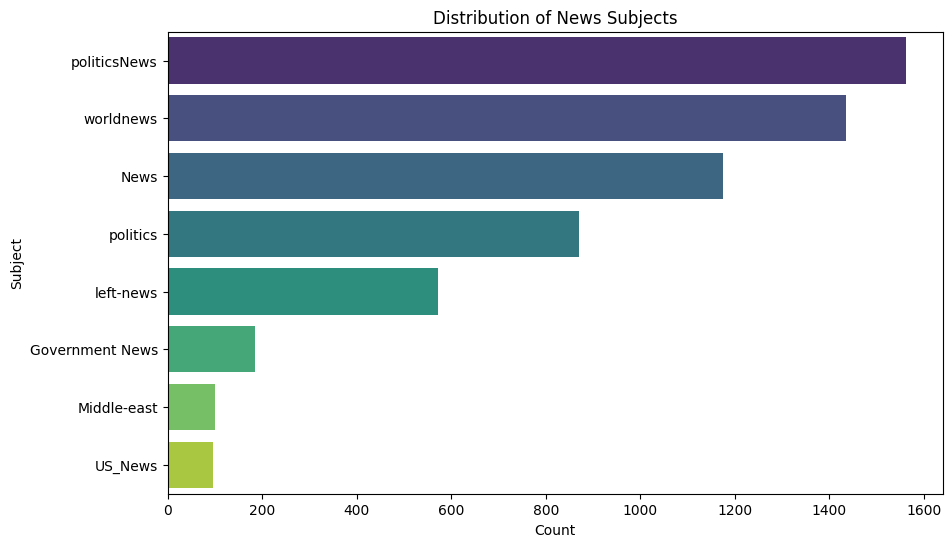

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='subject', order=df['subject'].value_counts().index, palette='viridis')
plt.title('Distribution of News Subjects')
plt.xlabel('Count')
plt.ylabel('Subject')
plt.show()

Now, let's plot the distribution of the 'label' column to check for class balance. This is crucial for understanding if our dataset is biased towards one class or another.

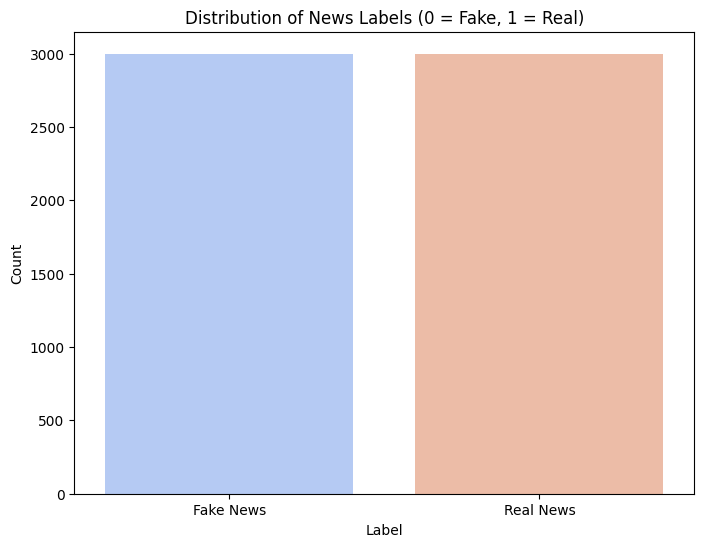

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label', palette='coolwarm')
plt.title('Distribution of News Labels (0 = Fake, 1 = Real)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'Real News'])
plt.show()

### Word Count Statistics


In [15]:
# Calculate word count for the 'text' column
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics for word count
print("Descriptive statistics for 'word_count' column:")
display(df['word_count'].describe())

Descriptive statistics for 'word_count' column:


,word_count
count,5995.000000
mean,403.924771
std,356.832757
min,0.000000
25%,204.000000
50%,359.000000
75%,509.000000
max,8135.000000


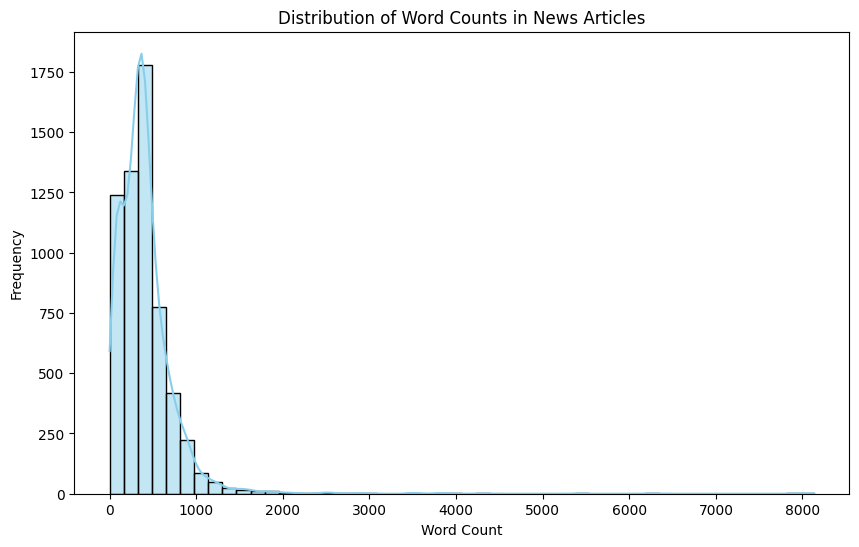

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Counts in News Articles')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

### Sentiment Analysis



In [21]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon
nltk.download('vader_lexicon', quiet=True)

True

In [22]:
# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    return sia.polarity_scores(text)

# Apply the function to the 'text' column
df['sentiment_scores'] = df['text'].apply(get_sentiment_scores)

# Extract compound, negative, neutral, and positive scores into separate columns
df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])
df['neg'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['neu'] = df['sentiment_scores'].apply(lambda x: x['neu'])
df['pos'] = df['sentiment_scores'].apply(lambda x: x['pos'])

# Display the first few rows with new sentiment columns
display(df[['text', 'compound', 'neg', 'neu', 'pos', 'label']].head())

,text,compound,neg,neu,pos,label
0,A whole lot of evangelical Trump voters just d...,0.9454,0.054,0.846,0.100,0
1,GENEVA (Reuters) - China signaled on Wednesday...,-0.9826,0.141,0.760,0.098,1
2,,0.0000,0.000,0.000,0.000,0
3,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,0.6008,0.084,0.818,0.097,0
4,WASHINGTON (Reuters) - Critics of a plan for t...,0.8957,0.059,0.848,0.093,1


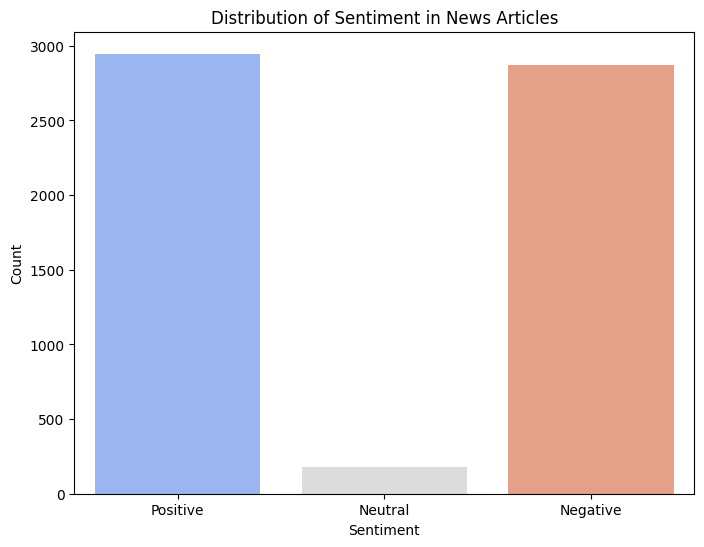

In [23]:
# Categorize sentiment based on compound score
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['compound'].apply(categorize_sentiment)

# Visualize the distribution of sentiment categories
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
plt.title('Distribution of Sentiment in News Articles')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

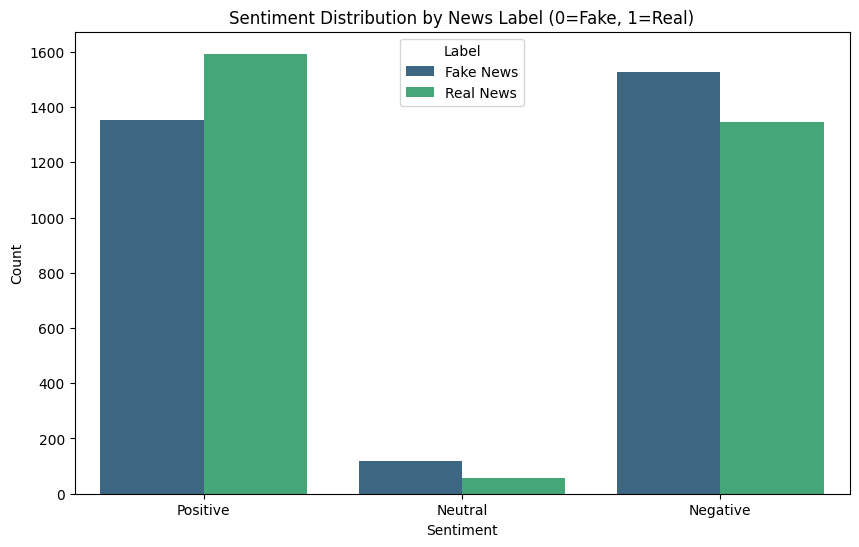

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment', hue='label', order=['Positive', 'Neutral', 'Negative'], palette='viridis')
plt.title('Sentiment Distribution by News Label (0=Fake, 1=Real)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.legend(title='Label', labels=['Fake News', 'Real News'])
plt.show()